In [424]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
import numpy as np

In [425]:
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [426]:
df = pd.read_csv('data/MarketingCampaign.csv', sep='\t')


In [427]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [428]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [429]:
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)


         ID  Year_Birth   Education Marital_Status  Income  Kidhome  Teenhome  \
10     1994        1983  Graduation        Married     NaN        1         0   
27     5255        1986  Graduation         Single     NaN        1         0   
43     7281        1959         PhD         Single     NaN        0         0   
48     7244        1951  Graduation         Single     NaN        2         1   
58     8557        1982  Graduation         Single     NaN        1         0   
71    10629        1973    2n Cycle        Married     NaN        1         0   
90     8996        1957         PhD        Married     NaN        2         1   
91     9235        1957  Graduation         Single     NaN        1         1   
92     5798        1973      Master       Together     NaN        0         0   
128    8268        1961         PhD        Married     NaN        0         1   
133    1295        1963  Graduation        Married     NaN        0         1   
312    2437        1989  Gra

In [430]:
df_cleaned = df.dropna(subset=['Income'])

In [431]:
print(df_cleaned['Education'].value_counts())
print(df_cleaned['Marital_Status'].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [432]:
keep_status = ['Married', 'Together', 'Single', 'Divorced']

# Thay thế các giá trị không nằm trong danh sách trên thành 'Other'
df_cleaned['Marital_Status'] = df_cleaned['Marital_Status'].apply(lambda x: x if x in keep_status else 'Other')

print(df_cleaned['Marital_Status'].value_counts())

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Other        83
Name: count, dtype: int64


In [433]:
from datetime import datetime

# Lấy năm hiện tại (hệ thống)
current_year = 2010

# Tạo cột Tuổi (Age)
df_cleaned['Age'] = current_year - df_cleaned['Year_Birth']

In [434]:
df_cleaned['Age'].max()

117

In [435]:
df_cleaned['Age'].min()

14

(array([ 43., 144., 193., 309., 388., 290., 287., 246., 207.,  91.,  15.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   1.]),
 array([ 14.  ,  19.15,  24.3 ,  29.45,  34.6 ,  39.75,  44.9 ,  50.05,
         55.2 ,  60.35,  65.5 ,  70.65,  75.8 ,  80.95,  86.1 ,  91.25,
         96.4 , 101.55, 106.7 , 111.85, 117.  ]),
 <BarContainer object of 20 artists>)

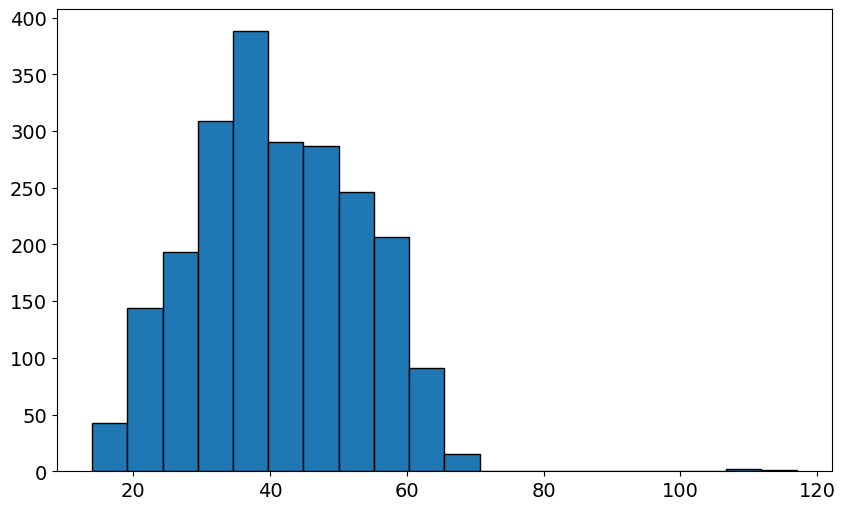

In [436]:
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['Age'], bins=20, edgecolor='black')


In [437]:
# TẠO CỘT TOTAL_KID 
df_cleaned['Total_Kid'] = df_cleaned['Kidhome'] + df_cleaned['Teenhome']
print(df_cleaned['Total_Kid'].value_counts().sort_index())

Total_Kid
0     633
1    1117
2     416
3      50
Name: count, dtype: int64


In [438]:
#  TẠO CỘT TỔNG SỐ LƯỢT MUA HÀNG (Total_Purchases)
purchases_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_cleaned['Total_Purchases'] = df_cleaned[purchases_cols].sum(axis=1)

#  TẠO CỘT TỔNG SỐ LẦN TƯƠNG TÁC KHUYẾN MÃI (Total_Promos)
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df_cleaned['Total_Promos'] = df_cleaned[cmp_cols].sum(axis=1)

In [439]:
print(df_cleaned['Z_CostContact'].value_counts())
print(df_cleaned['Z_Revenue'].value_counts())

Z_CostContact
3    2216
Name: count, dtype: int64
Z_Revenue
11    2216
Name: count, dtype: int64


In [440]:
df_cleaned.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Kid', 'Total_Purchases', 'Total_Promos'],
      dtype='str')

In [441]:
col_collections = ['Age', 'Education', 'Marital_Status', 'Complain' 
                   ,'Income', 'Kidhome','Recency','Total_Kid', 'Total_Purchases', 'Total_Promos',
                    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']


In [442]:
df_collections = df_cleaned[col_collections]

In [443]:
df_collections.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2216 non-null   int64  
 1   Education         2216 non-null   str    
 2   Marital_Status    2216 non-null   str    
 3   Complain          2216 non-null   int64  
 4   Income            2216 non-null   float64
 5   Kidhome           2216 non-null   int64  
 6   Recency           2216 non-null   int64  
 7   Total_Kid         2216 non-null   int64  
 8   Total_Purchases   2216 non-null   int64  
 9   Total_Promos      2216 non-null   int64  
 10  MntWines          2216 non-null   int64  
 11  MntFruits         2216 non-null   int64  
 12  MntMeatProducts   2216 non-null   int64  
 13  MntFishProducts   2216 non-null   int64  
 14  MntSweetProducts  2216 non-null   int64  
 15  MntGoldProds      2216 non-null   int64  
dtypes: float64(1), int64(13), str(2)
memory usage: 326.2 KB


In [444]:
df_collections.head()


,Age,Education,Marital_Status,Complain,Income,Kidhome,Recency,Total_Kid,Total_Purchases,Total_Promos,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,53,Graduation,Single,0,58138.0,0,58,0,25,1,635,88,546,172,88,88
1,56,Graduation,Single,0,46344.0,1,38,2,6,0,11,1,6,2,1,6
2,45,Graduation,Together,0,71613.0,0,26,0,21,0,426,49,127,111,21,42
3,26,Graduation,Together,0,26646.0,1,26,1,8,0,11,4,20,10,3,5
4,29,PhD,Married,0,58293.0,1,94,1,19,0,173,43,118,46,27,15


In [445]:
# Định nghĩa thứ tự học vấn từ thấp đến cao
edu_order = {
    'Basic': 1,
    'Graduation': 2,
    '2n Cycle': 3,
    'Master': 4,
    'PhD': 5
}

# Thay thế chữ bằng số vào thẳng cột Education
df_collections['Education'] = df_collections['Education'].map(edu_order)

# ==========================================
# ONE-HOT ENCODING CHO 'Marital_Status' (Không có thứ tự)
# ==========================================
# (Tùy chọn) Gom các nhóm quá nhỏ lại thành 'Other' nếu bạn chưa làm ở bước trước
keep_status = ['Married', 'Together', 'Single', 'Divorced']
df_collections['Marital_Status'] = df_collections['Marital_Status'].apply(lambda x: x if x in keep_status else 'Other')

# Mã hóa One-Hot cho Marital_Status và lưu vào biến mới df_encoded
df_encoded = pd.get_dummies(df_collections, columns=['Marital_Status'], dtype=int)

# --- IN THỬ KẾT QUẢ ĐỂ KIỂM TRA ---
print(df_encoded.head())

   Age  Education  Complain   Income  Kidhome  Recency  Total_Kid  \
0   53          2         0  58138.0        0       58          0   
1   56          2         0  46344.0        1       38          2   
2   45          2         0  71613.0        0       26          0   
3   26          2         0  26646.0        1       26          1   
4   29          5         0  58293.0        1       94          1   

   Total_Purchases  Total_Promos  MntWines  MntFruits  MntMeatProducts  \
0               25             1       635         88              546   
1                6             0        11          1                6   
2               21             0       426         49              127   
3                8             0        11          4               20   
4               19             0       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  Marital_Status_Divorced  \
0              172                88            88           

In [446]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      2216 non-null   int64  
 1   Education                2216 non-null   int64  
 2   Complain                 2216 non-null   int64  
 3   Income                   2216 non-null   float64
 4   Kidhome                  2216 non-null   int64  
 5   Recency                  2216 non-null   int64  
 6   Total_Kid                2216 non-null   int64  
 7   Total_Purchases          2216 non-null   int64  
 8   Total_Promos             2216 non-null   int64  
 9   MntWines                 2216 non-null   int64  
 10  MntFruits                2216 non-null   int64  
 11  MntMeatProducts          2216 non-null   int64  
 12  MntFishProducts          2216 non-null   int64  
 13  MntSweetProducts         2216 non-null   int64  
 14  MntGoldProds             2216 non-null  

In [447]:
df_encoded.head()

,Age,Education,Complain,Income,Kidhome,Recency,Total_Kid,Total_Purchases,Total_Promos,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,53,2,0,58138.0,0,58,0,25,1,635,88,546,172,88,88,0,0,0,1,0
1,56,2,0,46344.0,1,38,2,6,0,11,1,6,2,1,6,0,0,0,1,0
2,45,2,0,71613.0,0,26,0,21,0,426,49,127,111,21,42,0,0,0,0,1
3,26,2,0,26646.0,1,26,1,8,0,11,4,20,10,3,5,0,0,0,0,1
4,29,5,0,58293.0,1,94,1,19,0,173,43,118,46,27,15,0,1,0,0,0


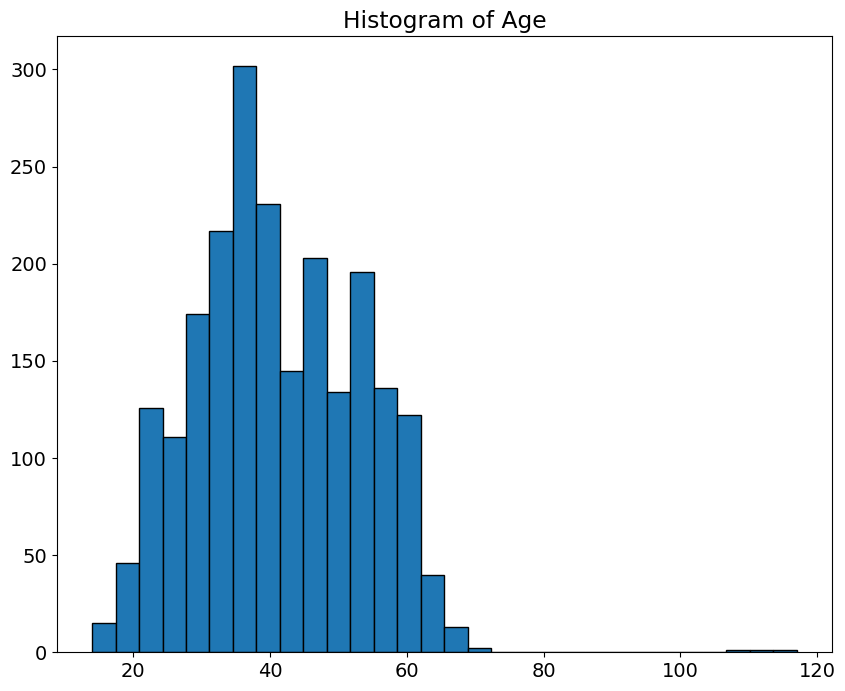

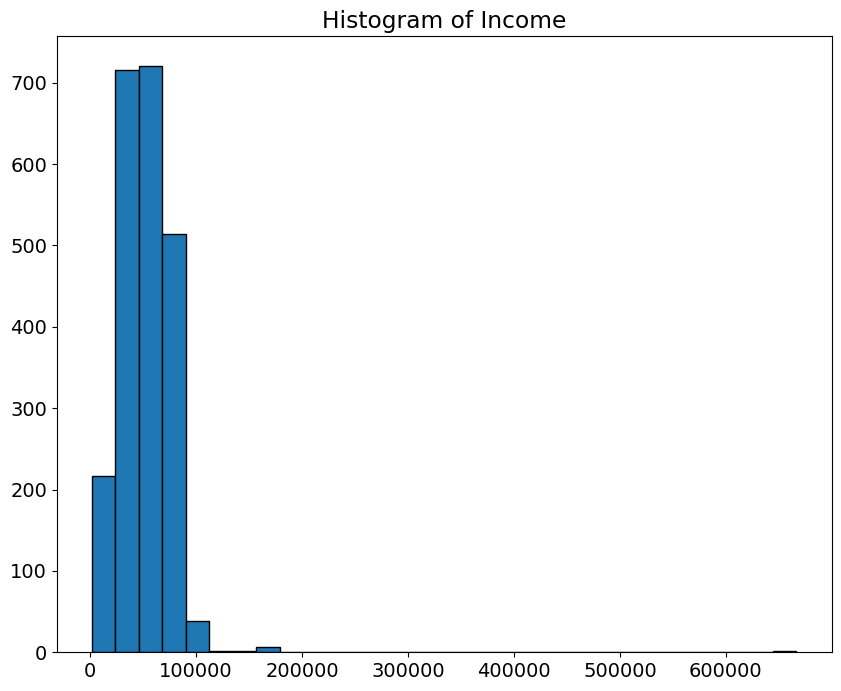

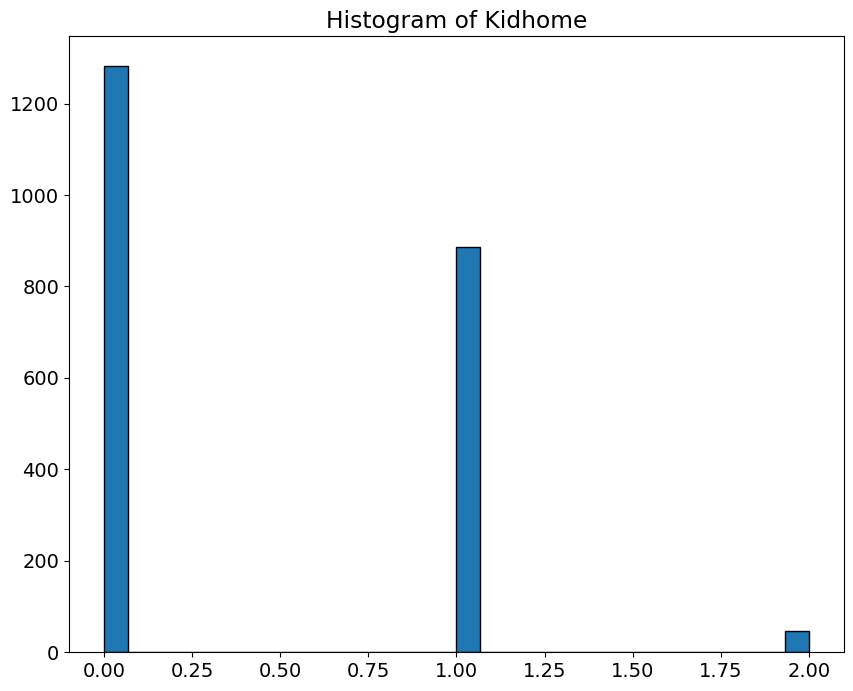

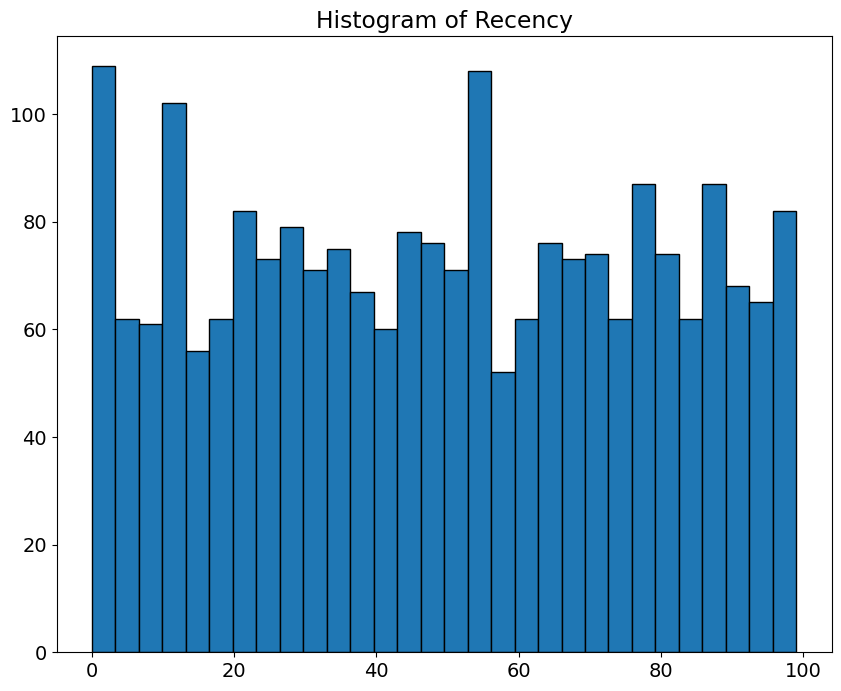

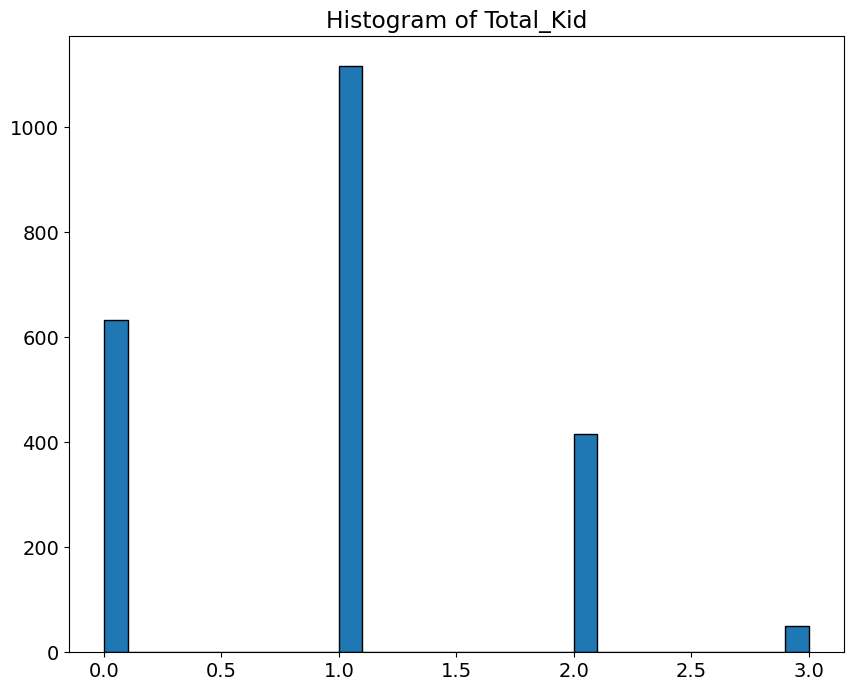

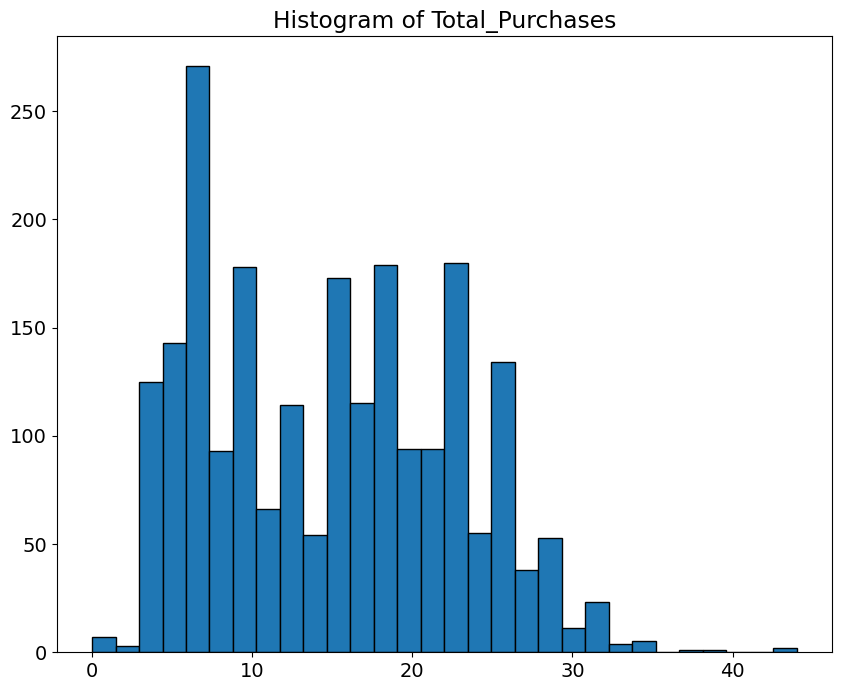

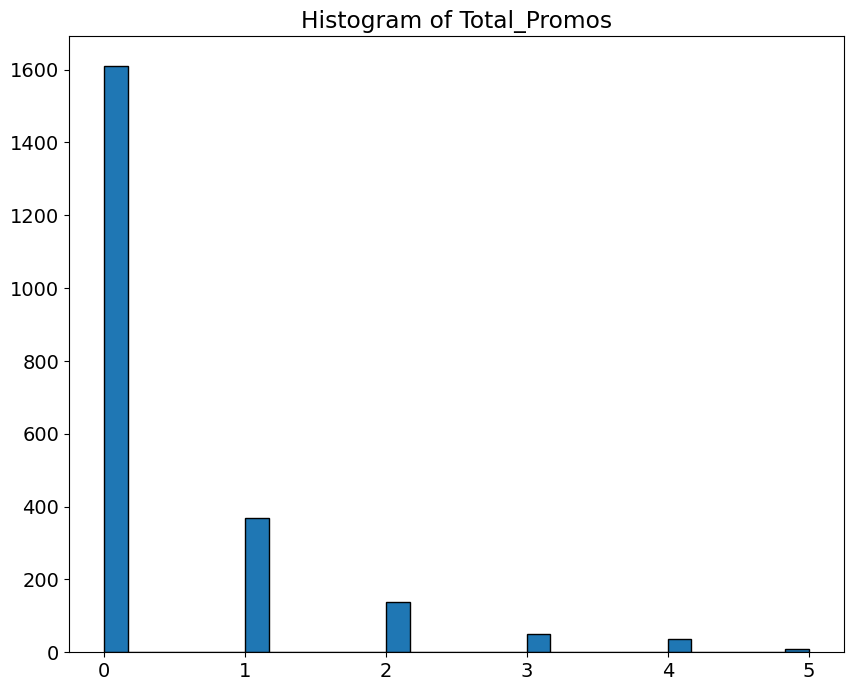

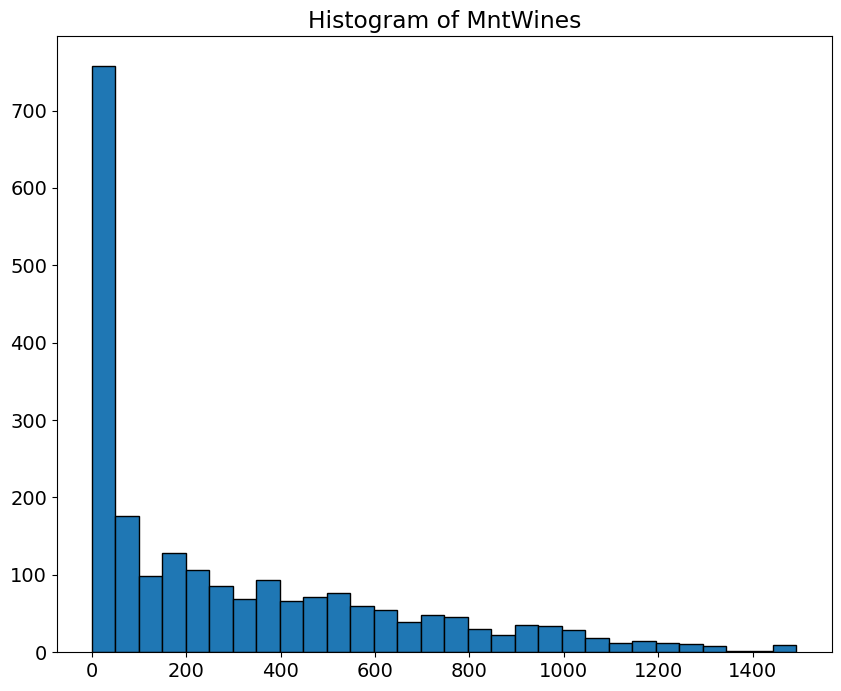

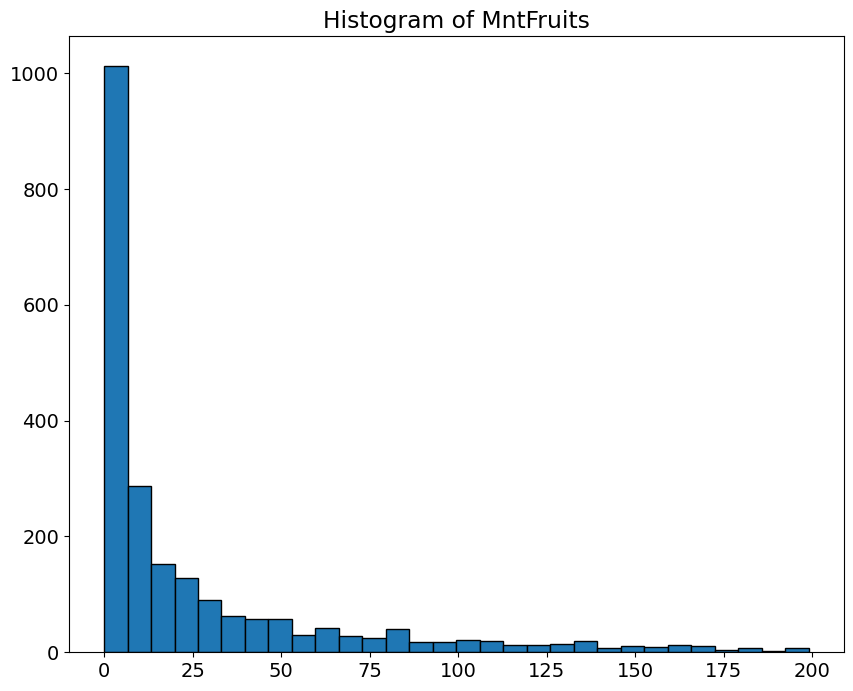

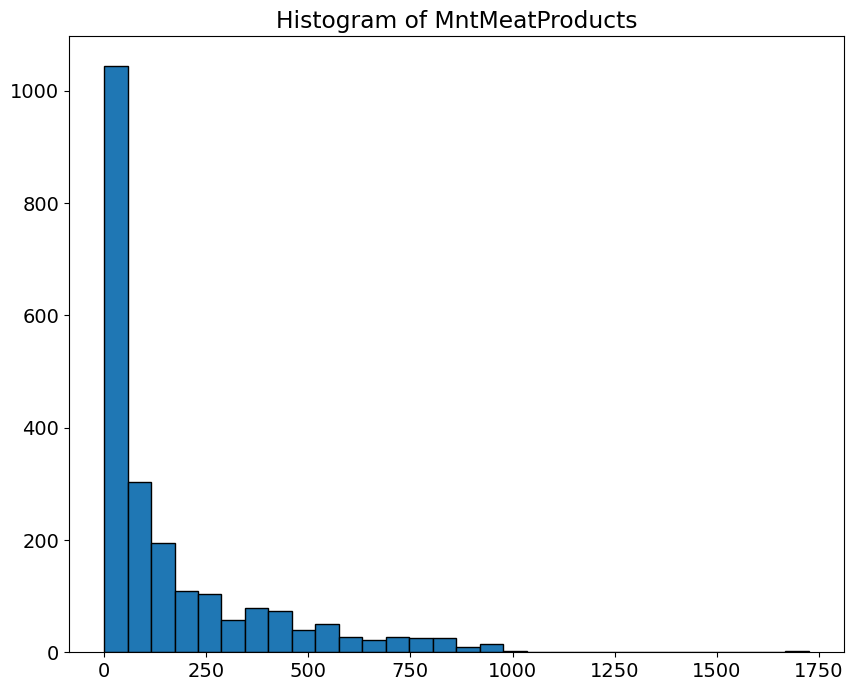

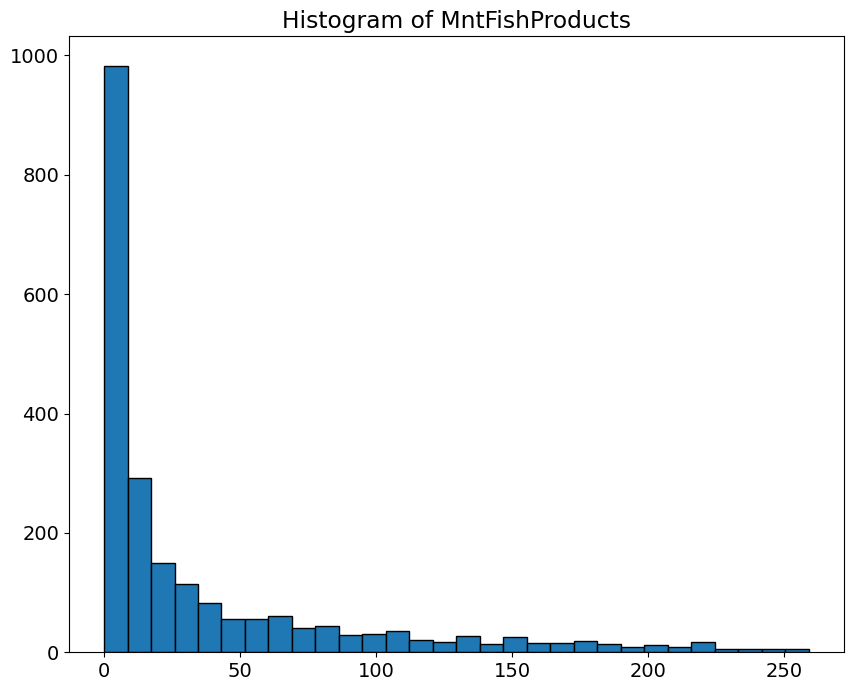

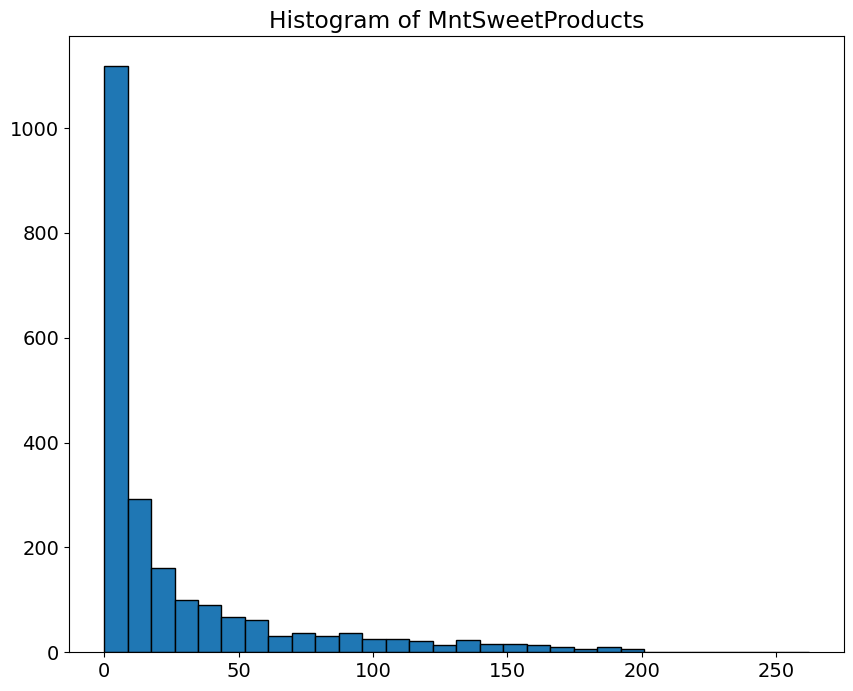

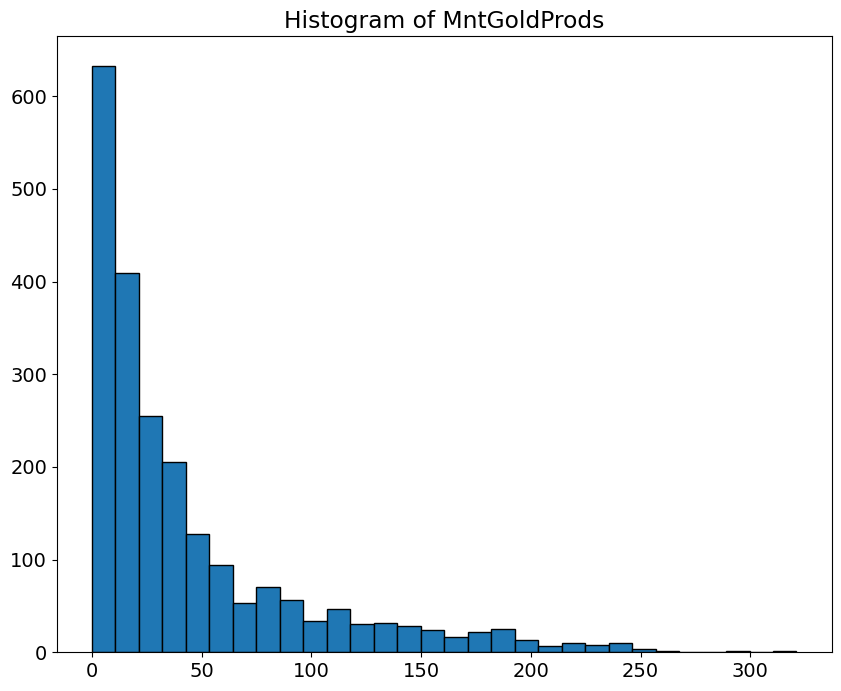

In [448]:
num_cols = ['Age', 'Income', 'Kidhome', 'Recency', 'Total_Kid', 'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

for col in num_cols:
    plt.hist(df_encoded[col], bins=30, edgecolor='k')
    plt.title(f'Histogram of {col}')
    plt.show()


In [449]:
# Giả sử 'df' là DataFrame dữ liệu của bạn đã được làm sạch và tạo biến
num_cols = ['Age', 'Income', 'Kidhome', 'Recency', 'Total_Kid', 
            'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 
            'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Tính chỉ số Skewness và sắp xếp từ cao xuống thấp để dễ nhìn
skewness_values = df_encoded[num_cols].skew().sort_values(ascending=False)

print("--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) CỦA CÁC BIẾN ---")
print(skewness_values)

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) CỦA CÁC BIẾN ---
Income              6.763487
Total_Promos        2.440020
MntSweetProducts    2.103328
MntFruits           2.101658
MntMeatProducts     2.025577
MntFishProducts     1.916369
MntGoldProds        1.839231
MntWines            1.170720
Kidhome             0.635610
Total_Kid           0.408748
Age                 0.353661
Total_Purchases     0.250936
Recency             0.001648
dtype: float64


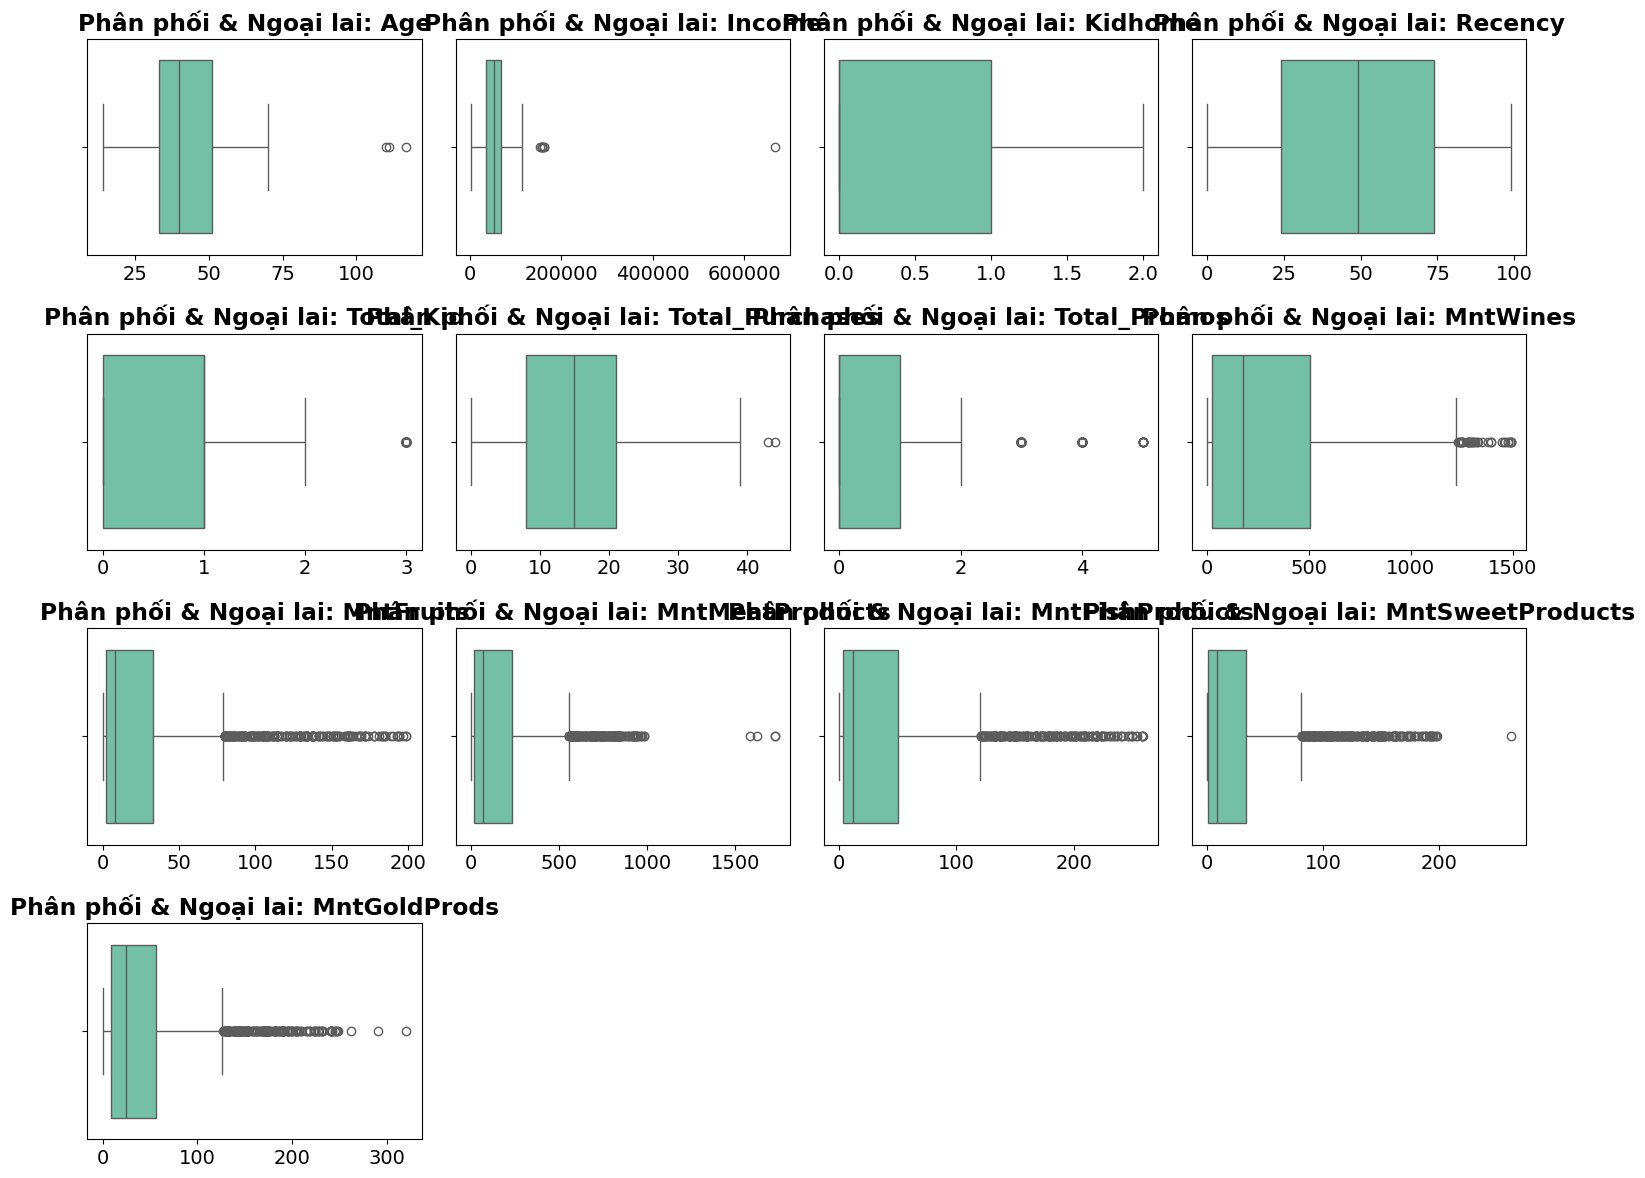

In [450]:
num_cols = ['Age', 'Income', 'Kidhome', 'Recency', 'Total_Kid', 'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

# Tạo khung vẽ gồm nhiều đồ thị con (3 hàng, 3 cột cho đẹp)x
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Dùng orient='h' để vẽ hộp nằm ngang cho dễ nhìn, hoặc 'v' (mặc định) cho hộp nằm dọc
    sns.boxplot(x=df_encoded[col], ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f'Phân phối & Ngoại lai: {col}', fontweight='bold')
    axes[i].set_xlabel('')

# Xóa các ô trống không dùng đến (vì có 13 biến nhưng có 16 ô)
for j in range(13, 16):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [451]:
df_encoded.columns

Index(['Age', 'Education', 'Complain', 'Income', 'Kidhome', 'Recency',
       'Total_Kid', 'Total_Purchases', 'Total_Promos', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Other', 'Marital_Status_Single',
       'Marital_Status_Together'],
      dtype='str')

In [452]:
# # CHuẩn hóa 
from sklearn.preprocessing import StandardScaler, RobustScaler
right_cols = [ 'Income', 'Total_Promos', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
norm_cols = ['Age', 'Kidhome', 'Recency', 'Total_Kid', 'Total_Purchases']

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df_encoded)

In [453]:

std_scaler = StandardScaler()


X_scaled = df_encoded.copy()
# Fit và Transform cho từng nhóm cột

# Bước A: Ép hình dáng đuôi dài về dạng hình chuông (Log Transformation) 
X_scaled[right_cols] = np.log1p(X_scaled[right_cols])
# Bước B: Đồng bộ thang đo (StandardScaler) sau khi đã có hình chuông
X_scaled[right_cols] = std_scaler.fit_transform(X_scaled[right_cols])

# Áp dụng StandardScaler cho nhóm phân phối chuẩn
X_scaled[norm_cols] = std_scaler.fit_transform(X_scaled[norm_cols])





In [454]:
# --- KIỂM TRA KẾT QUẢ ---
print("Dữ liệu sau khi Scale bằng 2 phương pháp khác nhau:")
print(X_scaled.head())

Dữ liệu sau khi Scale bằng 2 phương pháp khác nhau:
        Age  Education  Complain    Income   Kidhome   Recency  Total_Kid  \
0  0.986443          2         0  0.428623 -0.823039  0.310532  -1.264803   
1  1.236801          2         0 -0.019686  1.039938 -0.380509   1.405806   
2  0.318822          2         0  0.840808 -0.823039 -0.795134  -1.264803   
3 -1.266777          2         0 -1.114019  1.039938 -0.795134   0.070501   
4 -1.016420          5         0  0.433888  1.039938  1.554407   0.070501   

   Total_Purchases  Total_Promos  MntWines  MntFruits  MntMeatProducts  \
0         1.319446      1.005640  0.984704   1.430700         1.393131   
1        -1.157987     -0.568991 -1.214599  -0.987662        -1.398987   
2         0.797881     -0.568991  0.764006   1.063301         0.462699   
3        -0.897205     -0.568991 -1.214599  -0.403832        -0.695206   
4         0.537099     -0.568991  0.266718   0.981849         0.415994   

   MntFishProducts  MntSweetProducts  Mn

In [455]:
# # 2. Khởi tạo Scaler
# scaler = StandardScaler()

# # 3. Tạo một bản sao của DataFrame để không làm hỏng dữ liệu gốc
# X_scaled = df_encoded.copy()

# # 4. Chỉ chuẩn hóa đúng các cột số và ghi đè lại vào df_scaled
# X_scaled[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [456]:
X_scaled

,Age,Education,Complain,Income,Kidhome,Recency,Total_Kid,Total_Purchases,Total_Promos,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,0.986443,2,0,0.428623,-0.823039,0.310532,-1.264803,1.319446,1.005640,0.984704,1.430700,1.393131,1.578200,1.411177,1.061557,0,0,0,1,0
1,1.236801,2,0,-0.019686,1.039938,-0.380509,1.405806,-1.157987,-0.568991,-1.214599,-0.987662,-1.398987,-0.869044,-0.972475,-0.913938,0,0,0,1,0
2,0.318822,2,0,0.840808,-0.823039,-0.795134,-1.264803,0.797881,-0.568991,0.764006,1.063301,0.462699,1.315777,0.533457,0.496397,0,0,0,0,1
3,-1.266777,2,0,-1.114019,1.039938,-0.795134,0.070501,-0.897205,-0.568991,-1.214599,-0.403832,-0.695206,-0.084848,-0.537163,-1.033701,0,0,0,0,1
4,-1.016420,5,0,0.433888,1.039938,1.554407,0.070501,0.537099,-0.568991,0.266718,0.981849,0.415994,0.791674,0.684912,-0.271675,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.151917,2,0,0.530857,-0.823039,-0.104093,0.070501,0.406708,-0.568991,1.045674,0.981849,0.691689,0.737989,1.593610,1.857739,0,1,0,0,0
2236,1.904422,5,0,0.619003,2.902916,0.241428,2.741110,0.928273,1.005640,0.737433,-1.429313,-0.445712,-1.532123,-1.407787,-0.718687,0,0,0,0,1
2237,-1.016420,2,0,0.388876,-0.823039,1.450751,-1.264803,0.537099,1.005640,1.182541,1.050428,0.803801,0.578231,0.203058,0.075054,1,0,0,0,0
2238,1.069896,4,0,0.774319,-0.823039,-1.417072,0.070501,1.058664,-0.568991,0.766594,0.758712,0.794924,1.120193,0.748834,0.780699,0,0,0,0,1


In [457]:

from sklearn.cluster import KMeans


inertia = []
K_range = range(1, 11) # Khảo sát số cụm từ 1 đến 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # Chạy thuật toán trên không gian dữ liệu đã giảm chiều PCA
    inertia.append(kmeans.inertia_)



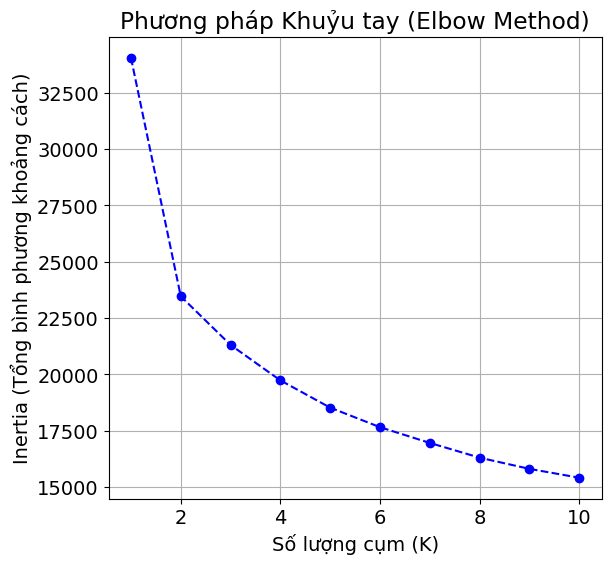

In [458]:
# --- BƯỚC 4: VẼ BIỂU ĐỒ TRỰC QUAN HÓA ---
plt.figure(figsize=(14, 6))

# Đồ thị 1: Phương pháp Khuỷu tay (Elbow)
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Inertia (Tổng bình phương khoảng cách)')
plt.title('Phương pháp Khuỷu tay (Elbow Method)')
plt.grid(True)

In [459]:

from sklearn.metrics import silhouette_score


silhouette_scores = []
K_range_sil = range(2, 12) 

# Chạy vòng lặp tính Silhouette Score cho từng K
for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Tính điểm Silhouette
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)


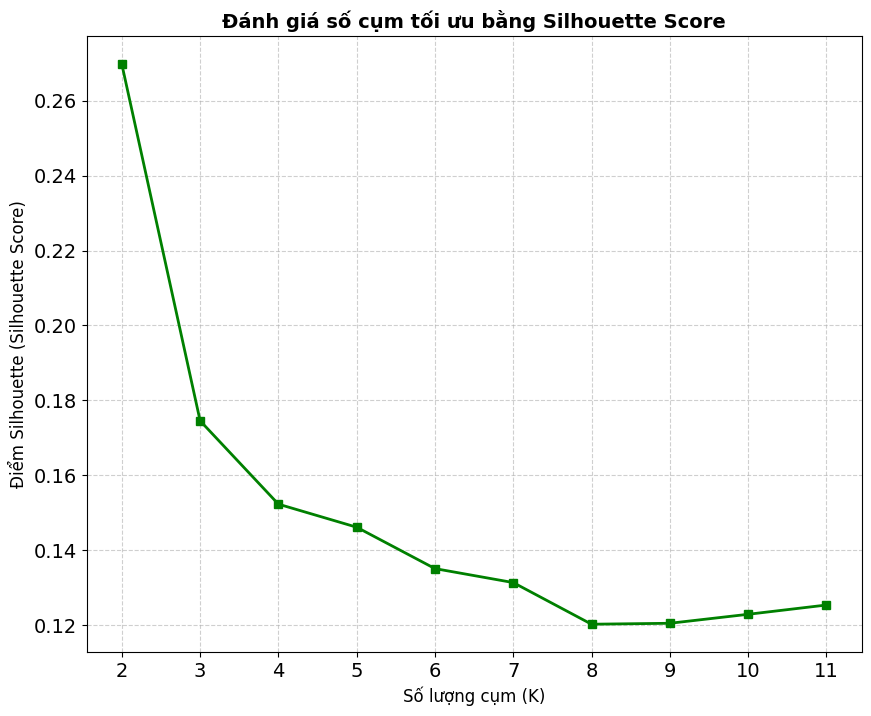

In [460]:

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
plt.plot(K_range_sil, silhouette_scores, marker='s', linestyle='-', color='green', linewidth=2)

plt.xlabel('Số lượng cụm (K)', fontsize=12)
plt.ylabel('Điểm Silhouette (Silhouette Score)', fontsize=12)
plt.title('Đánh giá số cụm tối ưu bằng Silhouette Score', fontsize=14, fontweight='bold')
plt.xticks(K_range_sil)
plt.grid(True, linestyle='--', alpha=0.6)

In [461]:
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(X_scaled)



In [462]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

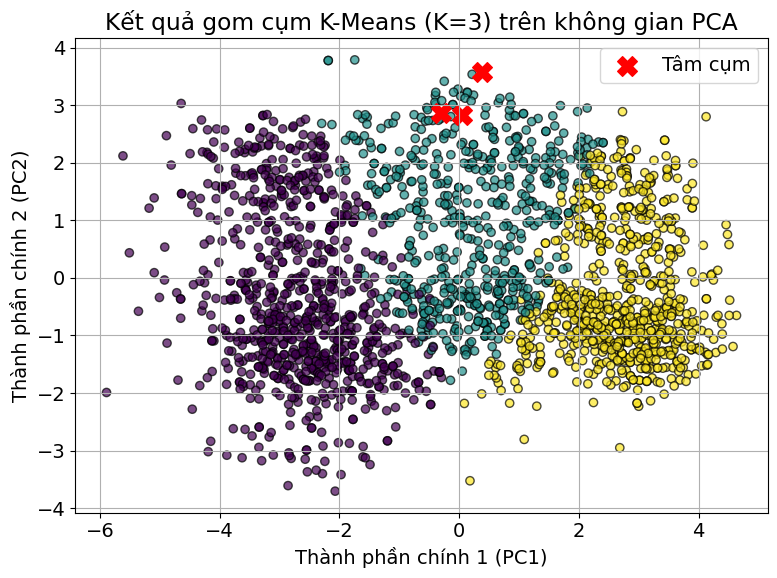

In [463]:
# Đồ thị 2: Trực quan hóa các cụm trên không gian PCA 2D
fig = plt.figure(figsize=(8, 6))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, edgecolors='k')
# Vẽ các tâm cụm (centroids)
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Tâm cụm')

plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.title(f'Kết quả gom cụm K-Means (K={optimal_k}) trên không gian PCA')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

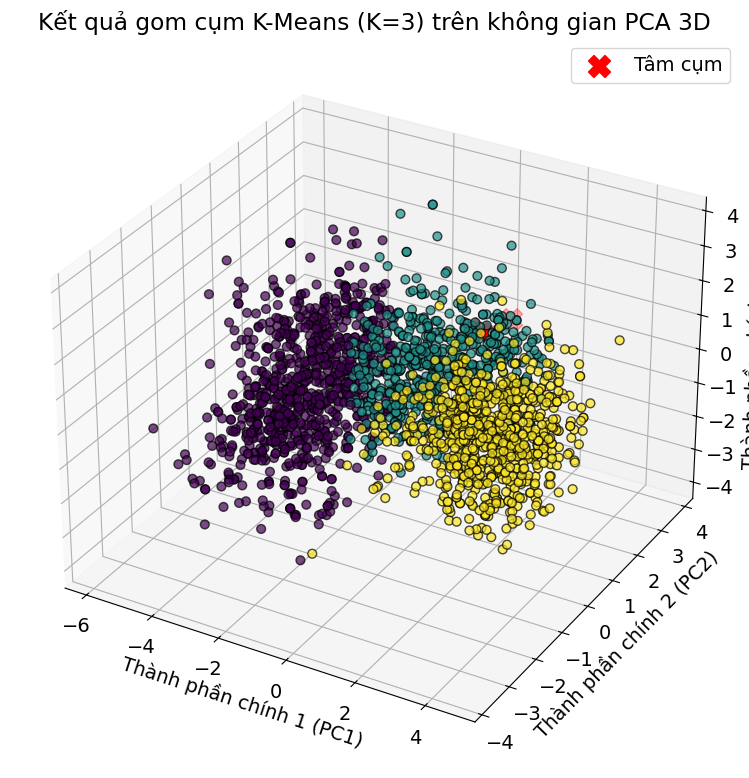

In [464]:

# Tạo khung hình tổng thể
fig = plt.figure(figsize=(10, 8))

# Khai báo trục tọa độ 3D
ax = fig.add_subplot(111, projection='3d')

# Vẽ các điểm dữ liệu trên không gian PCA 3D
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                     c=cluster_labels, cmap='viridis', 
                     alpha=0.7, edgecolors='k', s=40)

# Vẽ các tâm cụm (centroids) trong không gian 3D
ax.scatter(kmeans_optimal.cluster_centers_[:, 0], 
           kmeans_optimal.cluster_centers_[:, 1], 
           kmeans_optimal.cluster_centers_[:, 2], 
           s=250, c='red', marker='X', label='Tâm cụm')

# Gắn nhãn cho cả 3 trục
ax.set_xlabel('Thành phần chính 1 (PC1)')
ax.set_ylabel('Thành phần chính 2 (PC2)')
ax.set_zlabel('Thành phần chính 3 (PC3)')

# Thiết lập tiêu đề và chú thích
ax.set_title(f'Kết quả gom cụm K-Means (K={optimal_k}) trên không gian PCA 3D')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:

df_plot = df_encoded.copy()
df_plot['Cluster'] = cluster_labels

# --- 1. BẢNG TỔNG HỢP TRUNG BÌNH ---
insight_cols = ['Income', 'Age', 'Total_Kid', 'Total_Purchases', 
                'Total_Promos', 'MntWines', 'MntMeatProducts', 
                'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cluster_summary = df_plot.groupby('Cluster')[insight_cols].median().round(1)
print("=== GIÁ TRỊ TRUNG BÌNH THEO CỤM ===")
print(cluster_summary.T)

=== GIÁ TRỊ TRUNG BÌNH THEO CỤM ===
Cluster                 0        1        2
Income            32173.0  54349.0  71866.0
Age                  37.0     45.0     41.0
Total_Kid             1.0      1.0      0.0
Total_Purchases       7.0     17.0     21.0
Total_Promos          0.0      0.0      0.0
MntWines             15.0    275.0    515.0
MntMeatProducts      11.0     74.0    320.0
MntFruits             2.0      7.0     48.0
MntFishProducts       3.0     10.0     72.0
MntSweetProducts      2.0      6.5     49.0
MntGoldProds          8.0     28.0     59.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_33972\3406911786.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_plot, ax=axes[i],


ValueError: The palette dictionary is missing keys: {'2', '1', '0'}

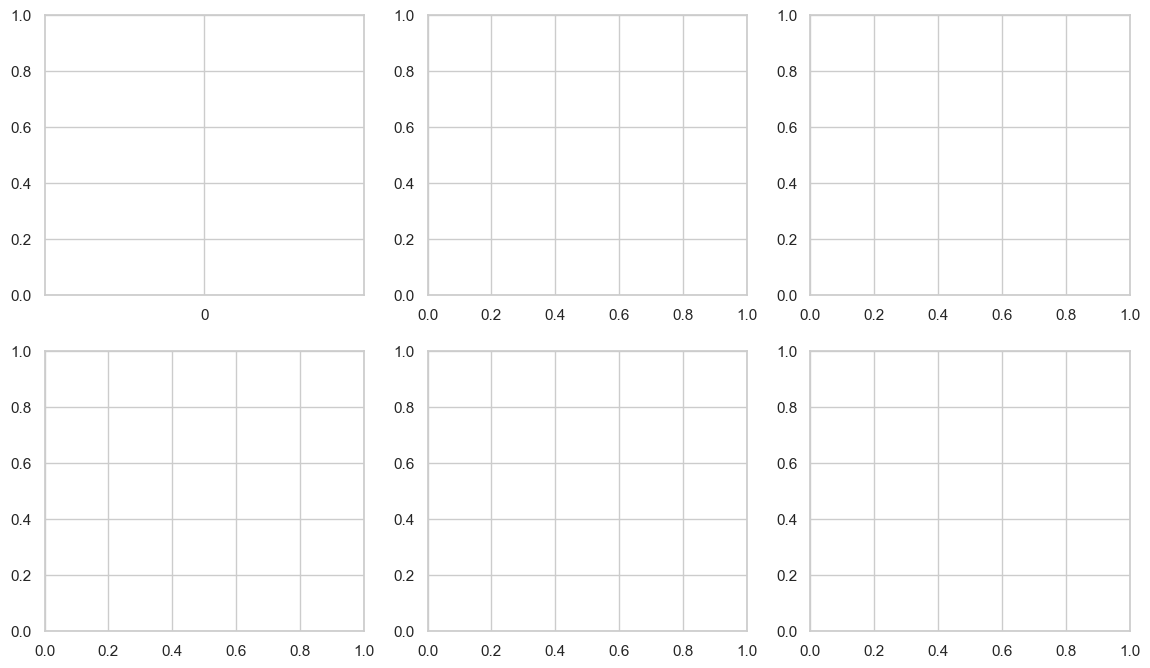

In [486]:

key_cols = ['Income', 'Total_Purchases', 'Total_Promos',
            'MntWines', 'MntMeatProducts', 'Total_Kid']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
cluster_palette = {0: '#378ADD', 1: '#639922', 2: '#BA7517'}

for i, col in enumerate(key_cols):
    sns.boxplot(x='Cluster', y=col, data=df_plot, ax=axes[i],
                palette=cluster_palette, order=[0, 1, 2])
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Cụm (Cluster)')
    axes[i].set_ylabel('')

plt.suptitle('Phân bố các biến chính theo Cụm', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

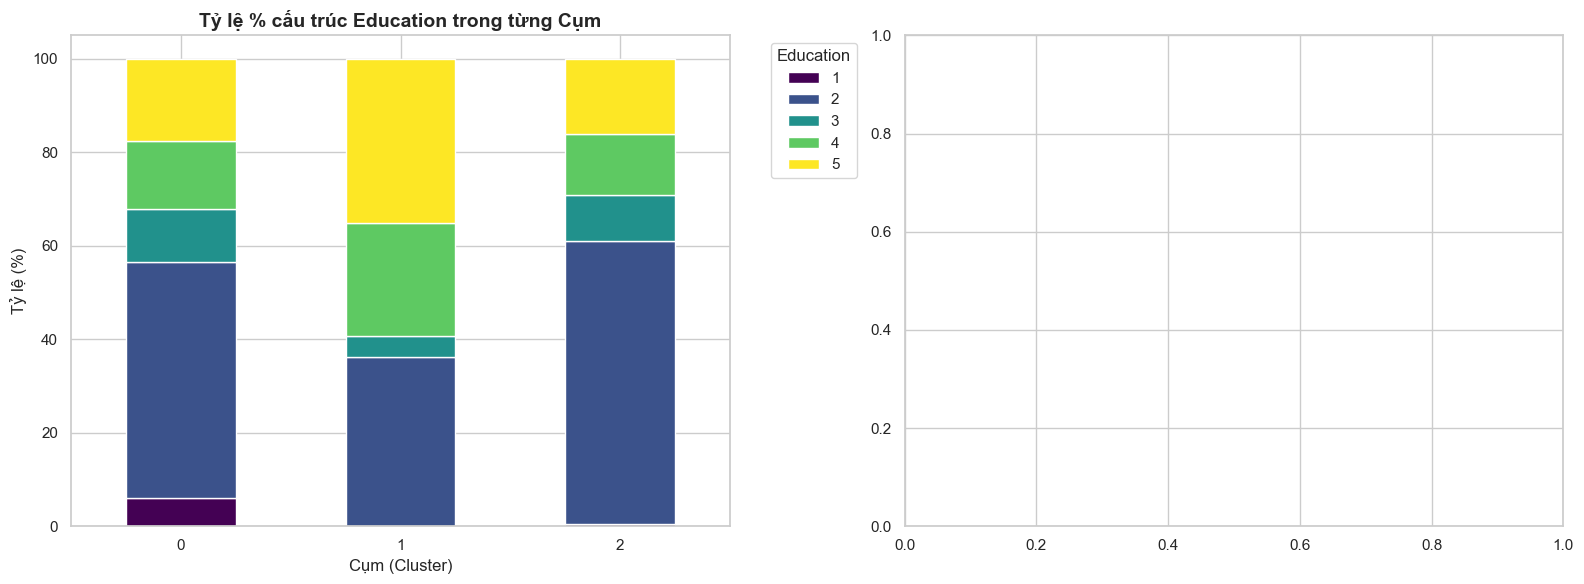

In [ ]:
# --- 4. NHẬN XÉT TỰ ĐỘNG ---
for i, row in cluster_summary.iterrows():
    print(f"\n{'='*45}")
    print(f"  CLUSTER {i}")
    print(f"  Income TB   : ${row['Income']:,.0f}")
    print(f"  Tổng mua    : {row['Total_Purchases']:.1f} lượt")
    print(f"  Trả lời KM  : {row['Total_Promos']:.1f} lần")
    print(f"  Số con TB   : {row['Total_Kid']:.1f}")
    print(f"  Chi Wines   : ${row['MntWines']:,.0f}")
    print(f"  Chi Meat    : ${row['MntMeatProducts']:,.0f}")

## Có sự khác nhau về Income và 'Total_Kid', 'Total_Spent', 'Total_Purchases', 'Total_Promos'

## income cao thì total-spent cao và total_purchases cao 

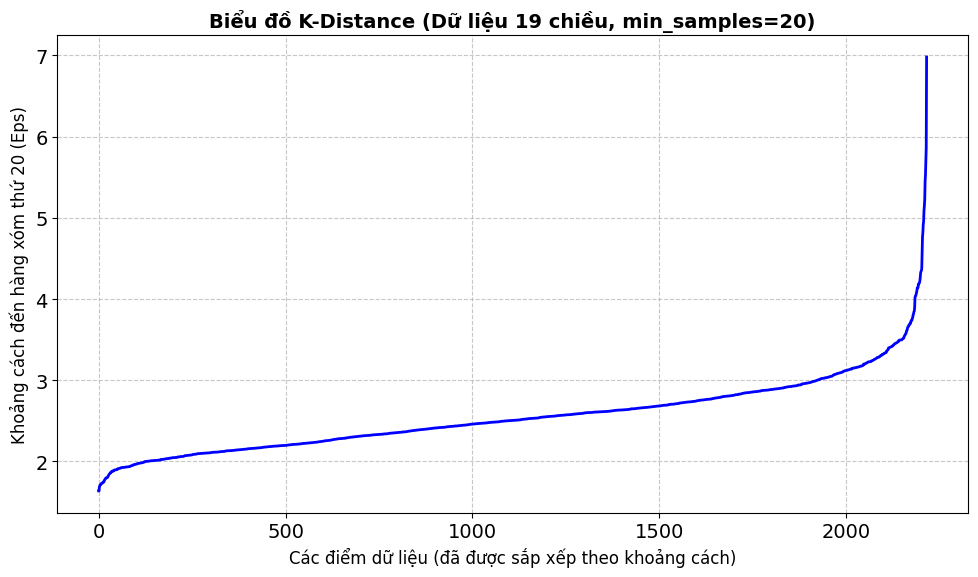

In [466]:

from sklearn.neighbors import NearestNeighbors

# 1. Khai báo số chiều và min_samples
D = 19
min_samples = D + 1  # Kết quả là 20

# 2. Khởi tạo thuật toán tìm hàng xóm gần nhất
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled) # Hoặc df_scaled của bạn
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 3. Lấy khoảng cách của người hàng xóm xa nhất (cột cuối cùng: index = -1)
# và sắp xếp tăng dần
k_distances = np.sort(distances[:, -1], axis=0)

# 4. Vẽ biểu đồ K-Distance
plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='blue', linewidth=2)
plt.xlabel('Các điểm dữ liệu (đã được sắp xếp theo khoảng cách)', fontsize=12)
plt.ylabel(f'Khoảng cách đến hàng xóm thứ {min_samples} (Eps)', fontsize=12)
plt.title(f'Biểu đồ K-Distance (Dữ liệu {D} chiều, min_samples={min_samples})', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Số lượng cụm tìm được: 1
Số lượng điểm nhiễu (Outliers): 55


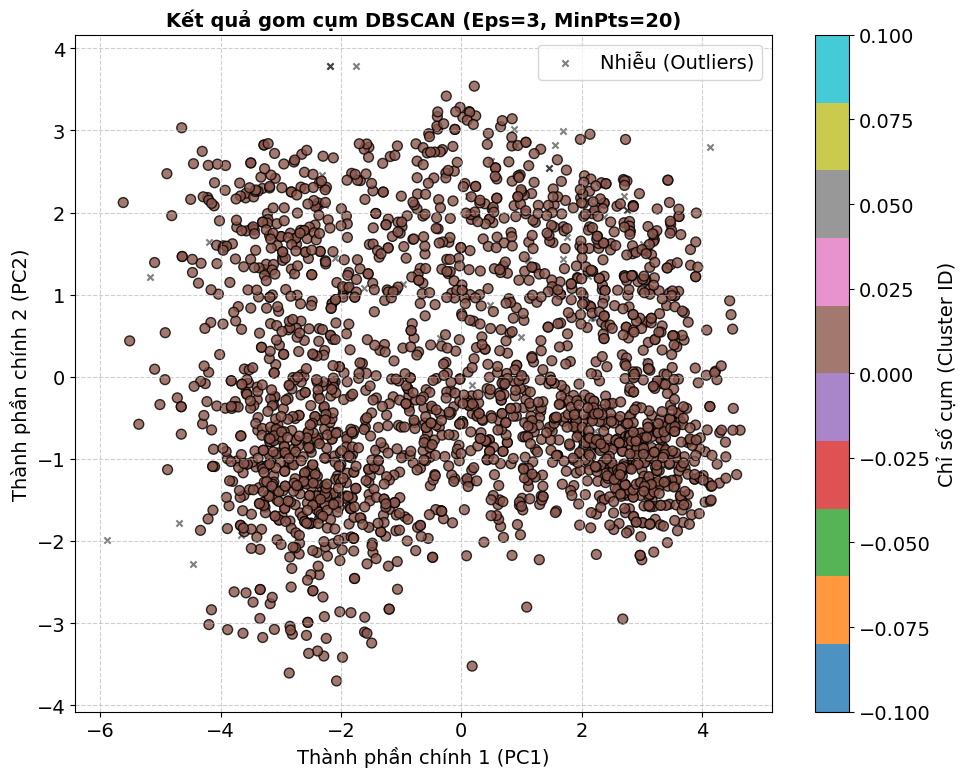

In [467]:
from sklearn.cluster import DBSCAN

optimal_eps = 3

# Khởi tạo và chạy DBSCAN
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

# Kiểm tra xem DBSCAN đã tìm ra bao nhiêu cụm (không tính cụm nhiễu -1)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Số lượng cụm tìm được: {n_clusters}")
print(f"Số lượng điểm nhiễu (Outliers): {n_noise}")

# Vẽ biểu đồ kết quả gom cụm
plt.figure(figsize=(10, 8))

# Tách riêng dữ liệu nhiễu (label == -1) và dữ liệu thuộc cụm (label != -1)
# 1. Vẽ các điểm nhiễu (Màu đen, hình dấu x, nhỏ hơn)
noise_mask = db_labels == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
            c='black', marker='x', s=20, alpha=0.5, label='Nhiễu (Outliers)')

# 2. Vẽ các cụm bình thường
core_mask = db_labels != -1
scatter = plt.scatter(X_pca[core_mask, 0], X_pca[core_mask, 1], 
                      c=db_labels[core_mask], cmap='tab10', 
                      s=50, alpha=0.8, edgecolors='k')

plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.title(f'Kết quả gom cụm DBSCAN (Eps={optimal_eps}, MinPts={min_samples})', fontsize=14, fontweight='bold')

# Thêm thanh màu để biết các cụm
plt.colorbar(scatter, label='Chỉ số cụm (Cluster ID)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Gán kết quả vào DataFrame gốc nếu cần
# df_original['DBSCAN_Cluster'] = db_labels